# NorDex Shift Performance Analytics & Optimization

## Project Introduction
NorDex Manufacturing AS is a Bergen-based precision parts manufacturer founded in 1998, 
serving the **automotive** and **industrial equipment** sectors across Northern Europe. 
With **~1,000 employees** and revenues exceeding **€120 million**, the company runs 
three fully automated production plants across Norway.


### The Problem
Despite similar machinery, processes, and staffing across all shifts, NorDex faces a 
consistent performance imbalance across its three eight-hour shifts, Morning, Evening, 
and Night, with output variability of up to **25%**, an **8% OEE decline**, and a 
**29.6 percentage point** efficiency gap between the best and worst performing shifts.


### Objectives
- Analyze production output, machine health, operator skill mix, and downtime patterns
- Identify root causes of shift-level performance gaps through EDA
- Build predictive models to forecast shift efficiency scores
- Optimize workforce scheduling and machine allocation
- Track all experiments using MLflow for reproducibility

# Importing Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Connecting to the SQL Database

In [33]:
import sqlite3

connection = sqlite3.connect('Shiftdata.db')
cursor = connection.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[]


In [34]:
import os
print(os.listdir('..'))


['LICENSE', 'requirements.txt', 'README.md', '.gitignore', 'nordex_env', 'ShiftData.db', '.git', 'notebooks']


In [35]:
import sqlite3
connection = sqlite3.connect('../ShiftData.db')
Shift_Data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


In [36]:
import sqlite3
connection = sqlite3.connect('/Users/esther/Desktop/Nordex-Shift-Performance-Optimization/ShiftData.db')
Shift_Data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


### Basic Dataset Overview

1. **Column Inspection**
   - Listed and reviewed all column names using `Shift_Data.columns`

2. **Dataset Dimensions**
   - Determined the number of rows and columns using `Shift_Data.shape`

3. **Data Type Formatting**
   - Ensured each column is assigned the appropriate data type:
     - Dates formatted as `datetime`
     - Categorical fields formatted as `category`
     - Numerical values correctly formatted

4. **Duplicate Records Check**
   - Identified and quantified duplicate entries using `df.duplicated().sum()`

5. **Missing Values Assessment**
   - Detected and summarized missing values across all columns using `df.isna().sum()`

6. **Statistical Summary**
   - Examined the statistical distribution of numerical features using `df.describe()`:
     - Mean
     - Standard Deviation
     - Minimum
     - Maximum

In [37]:
# 1. Dataset Info - Overview of columns, non-null counts, data types and memory usage

Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [38]:
# 2. Column Inspection - List and review all column names

Shift_Data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [39]:
# 3. Dataset Dimensions - Number of rows and columns

Shift_Data.shape

(296334, 31)

In [40]:
##### Convert all columns with date-like values into an appropriate datetime data type to 
# ensure accurate time-based analysis and operations.

Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['timestamp'] = pd.to_datetime(Shift_Data['timestamp'])

/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_1729/153272821.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_1729/153272821.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])


In [41]:
# Confirming the data types after conversion

Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [42]:
# 5. Duplicate Records Check - Identify and count duplicate entries

Shift_Data.duplicated().sum()

np.int64(0)

In [43]:
# 6. Missing Values Assessment - Detect missing values across all columns

Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [44]:
# 7. Statistical Summary - Distribution of numerical features

Shift_Data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity,timestamp
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000,295129
mean,2.048142,2026-05-25 14:23:06.478770688,2026-05-25 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118,2024-02-15 04:22:59.795276288
min,1.000000,2026-05-25 06:00:00,2026-05-25 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000,2024-01-01 08:00:00
25%,1.000000,2026-05-25 06:00:00,2026-05-25 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000,2024-01-23 08:00:00
50%,2.000000,2026-05-25 14:00:00,2026-05-25 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000,2024-02-15 00:00:00
75%,3.000000,2026-05-25 22:00:00,2026-05-25 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000,2024-03-09 00:00:00
max,3.000000,2026-05-25 22:00:00,2026-05-25 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000,2024-03-31 16:00:00
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084,NaN


## Filling Missing Values

- **`Shift_Data.isna().sum()`** - identifies how many missing values exist in each column
- **`Shift_Data.sort_values(by="date")`** - sorts the dataset chronologically to:
  - See trends over time
  - Spot anomalies in sequence
  - Enable accurate time-based calculations
- **Mean Imputation** - missing values are filled with the mean of their respective column

In [45]:
# Checking for trends over time, spot anomalies in sequence, and makes time-based calculations 

Shift_Data =Shift_Data.sort_values(by="date")

In [46]:
# Filling Temperature and Humidity columns with the mean value of each column
Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method='ffill').fillna(Shift_Data['temperature'].mean())
Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method='ffill').fillna(Shift_Data['humidity'].mean())

# Fill timestamp column with the mean value of the column
Shift_Data['timestamp'] = Shift_Data['timestamp'].fillna(method='ffill')

/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_1729/801928811.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method='ffill').fillna(Shift_Data['temperature'].mean())
/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_1729/801928811.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method='ffill').fillna(Shift_Data['humidity'].mean())
/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_1729/801928811.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['timestamp'] = Shift_Data['timestamp'].fillna(method='ffill')


In [47]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [48]:
# Fill categorical columns 
Shift_Data['issue_type'] = Shift_Data['issue_type'].fillna("No Issue")
Shift_Data['resolved_by'] = Shift_Data['resolved_by'].fillna("No Maintenance")

# Filling downtime column
Shift_Data['maintenance_downtime'] = Shift_Data['maintenance_downtime'].fillna(0)

# DROPPING  maintenance_id  
Shift_Data = Shift_Data.drop(columns=['maintenance_id'])

In [49]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [50]:
Shift_Data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

## Exploratory Data Analysis (EDA)

#### Numerical Data Analysis
I examined and interpreted numerical data to uncover patterns, trends, and insights.

**Visualizations Created:**

- **Histograms** - to visualize the distribution of all numerical columns:
  - Units Produced
  - Defects
  - Cycle Time
  - Efficiency
  - Runtime
  - Downtime
  - Temperature
  - Humidity

- **Boxplots** - to identify outliers and understand the data spread for each numerical variable

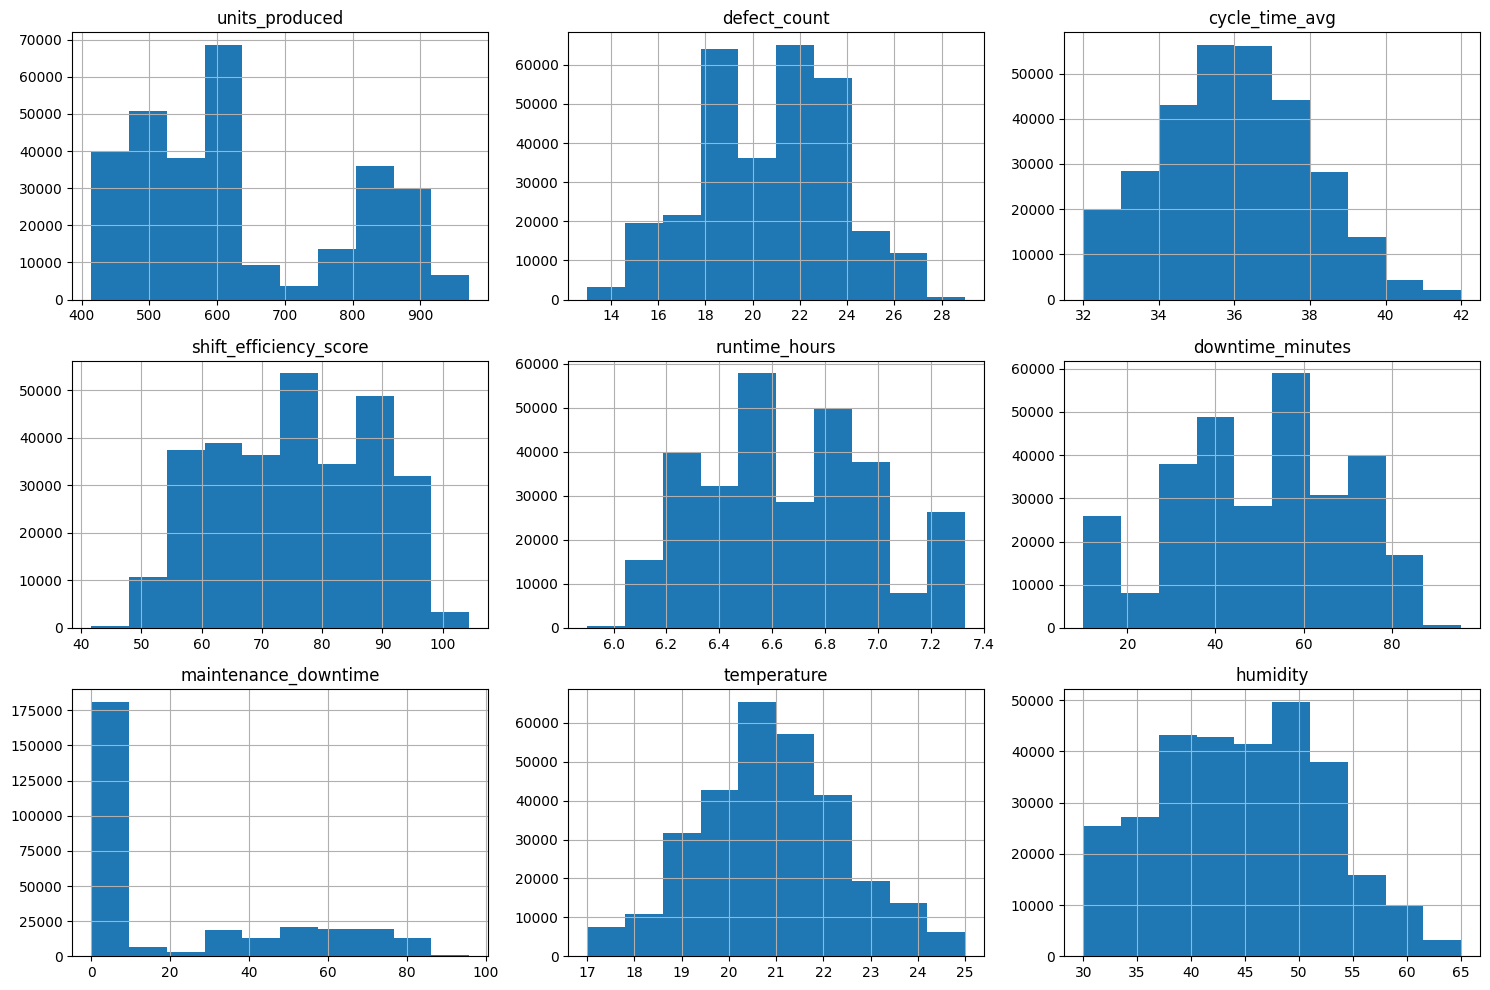

In [51]:
## Numerical Data Analysis

num_cols = [
    "units_produced", "defect_count", "cycle_time_avg", 
    "shift_efficiency_score", "runtime_hours", "downtime_minutes", "maintenance_downtime", 
    "temperature", "humidity"
]

Shift_Data[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

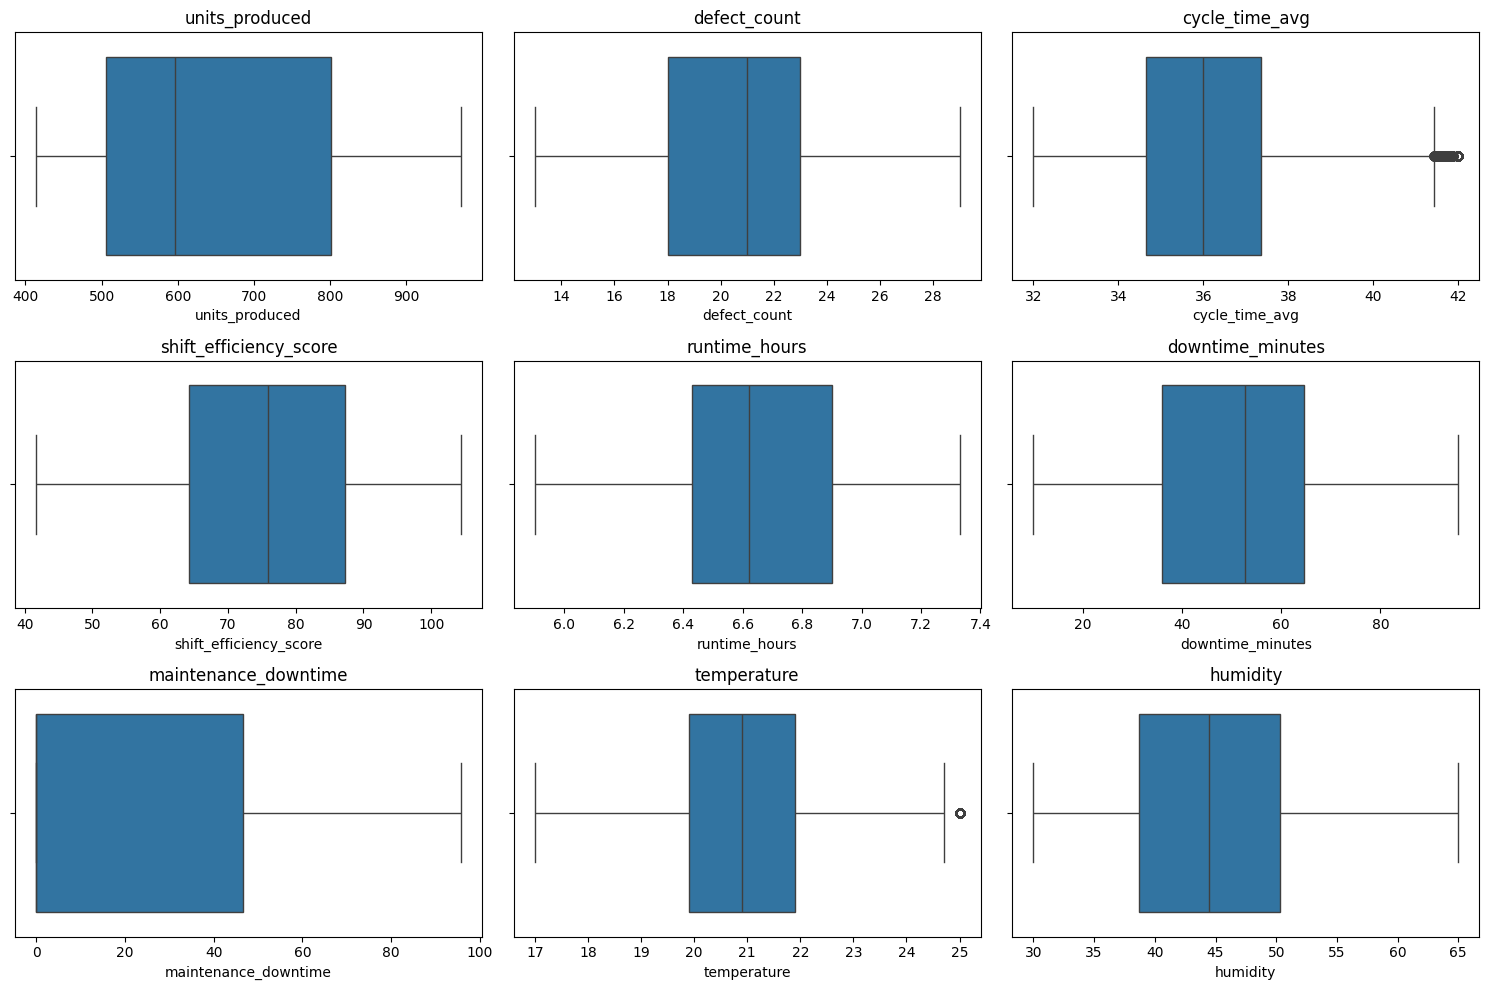

In [52]:
## Using the boxplot to check for outliers in the numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=Shift_Data[col])
    plt.title(col)
plt.tight_layout()
plt.show()


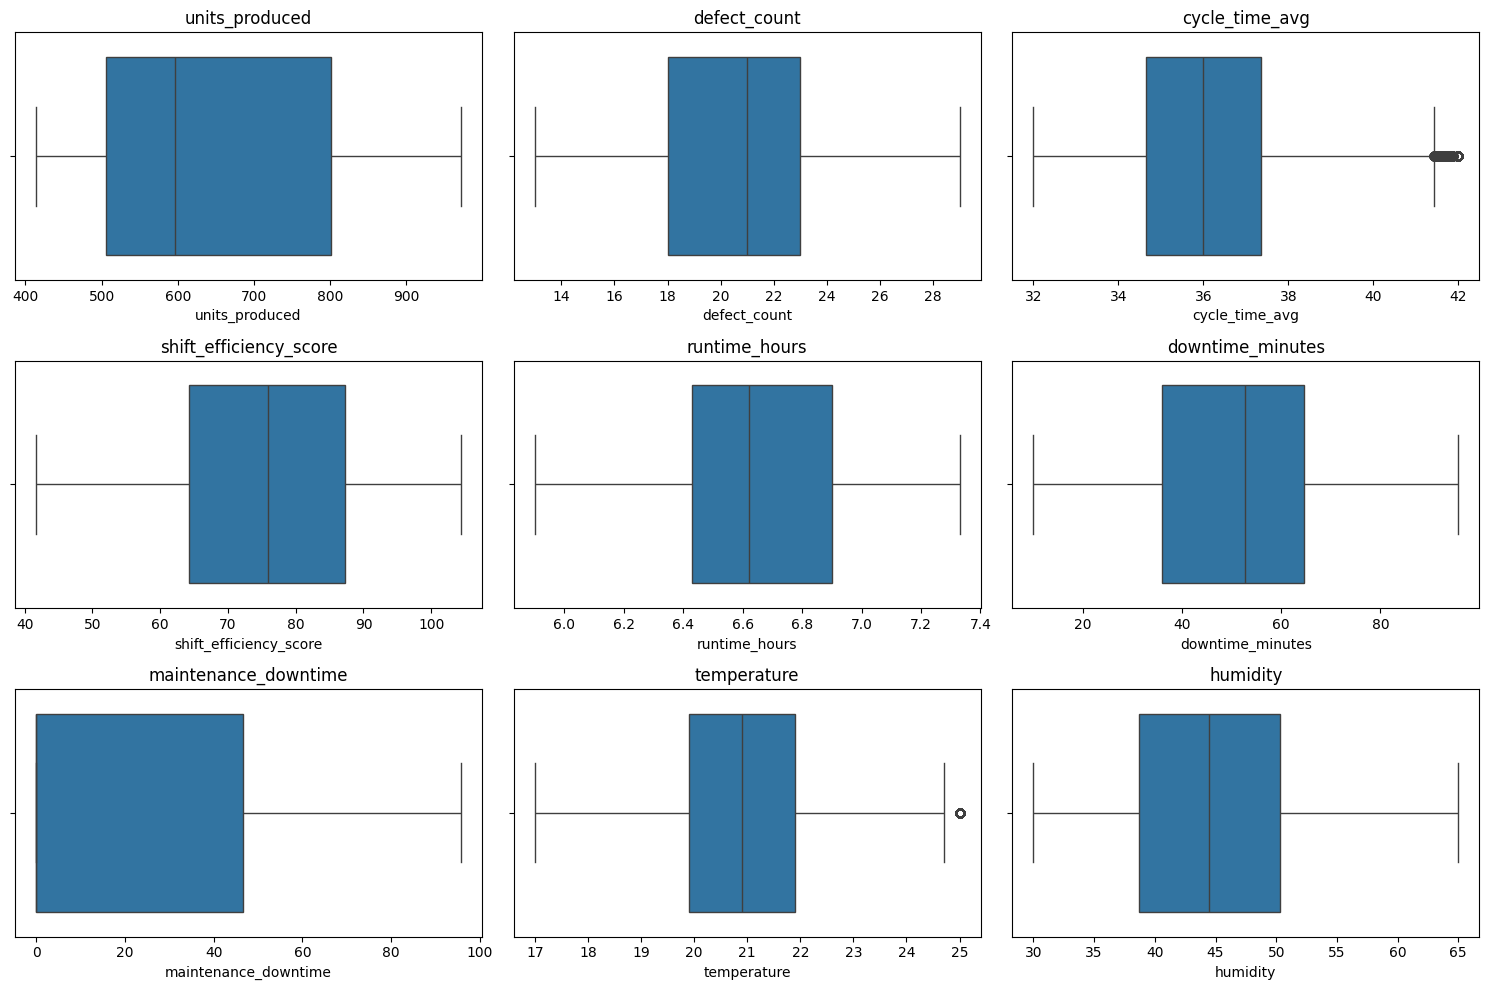

In [53]:
## Using the boxplot to check for outliers in the numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=Shift_Data, x=col)
    plt.title(col)
plt.tight_layout()
plt.show()

#### Categorical Variables Analysis
I examined and interpreted categorical data to understand the frequency and distribution of each variable.

**Analysis Performed:**

- **Value Counts** - displayed value counts for all categorical columns:
  - Shift Name
  - Experience Level
  - Skill Category
  - Machine Status
  - Issue Type
  - Defect Type
  - Severity
  - Inspection Result

- **Bar Charts** - created in a 4x2 grid layout to visualize the frequency distribution of each categorical variable

In [54]:
# Categorical Data Analysis

Categorical_cols = ['shift_name', 'issue_type', 'resolved_by'
                    , 'machine_status', 'defect_type', 'inspection_result',
                    'severity', 'experience_level'
                    ]
for column in Categorical_cols:
    print(f"Value counts for {column}:\n")
    print(Shift_Data[column].value_counts())

Value counts for shift_name:

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for issue_type:

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for resolved_by:

resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07            12427
TECH_08            12290
TECH_02            12065
TECH_10            11977
TECH_05            11743
TECH_04            11275
TECH_01            10522
TECH_09            10441
TECH_06             9954
Name: count, dtype: int64
Value counts for machine_status:

machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
Value counts for defect_type:

defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
Value counts for inspection_result:

inspec

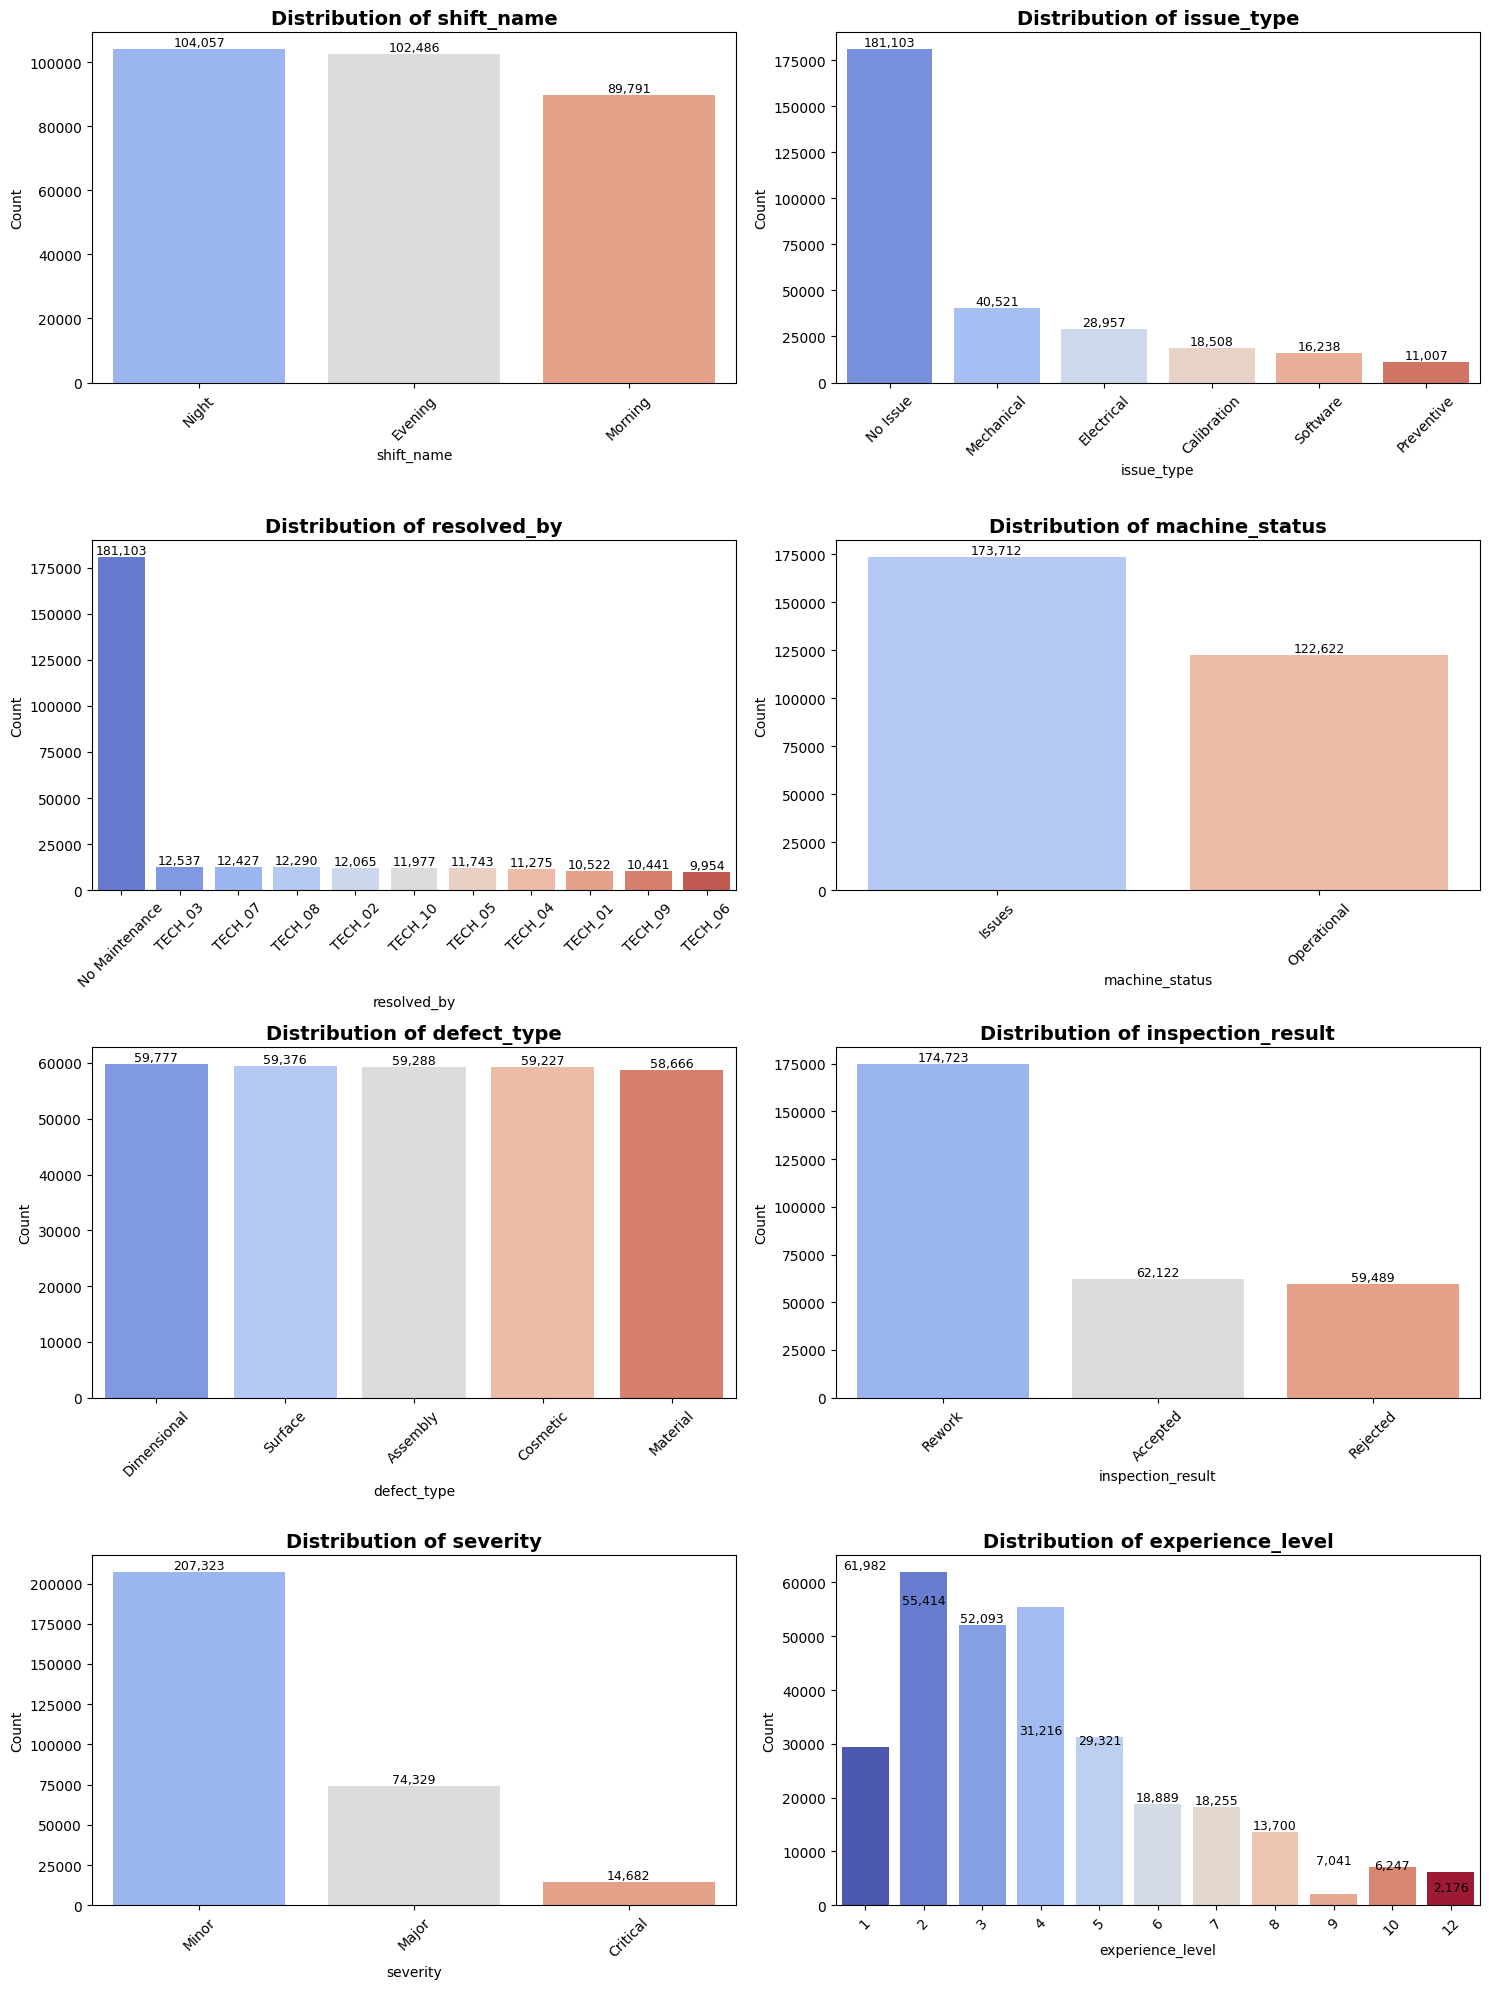

In [56]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

axes = axes.flatten()

for index, column in enumerate(Categorical_cols):
    # Get the value counts
    counts = Shift_Data[column].value_counts().reset_index()
    counts.columns = [column, 'count']

    sns.barplot(data=counts, x=column, y='count', palette="coolwarm", 
                ax=axes[index], hue=column, legend=False)

    # Plot customization
    axes[index].tick_params(axis='x', rotation=45)
    axes[index].set_title(f"Distribution of {column}", fontsize=14, fontweight='bold')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Count")

    # Add value labels on top of bars
    for j, v in enumerate(counts['count']):
        axes[index].text(j, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Operational Performance During Maintenance vs No Maintenance

#### Maintenance Flag Analysis
I analyzed numerical metrics segmented by maintenance flag to compare performance across maintenance conditions.

**Analysis Performed:**

- **Grouped Metrics** - numerical metrics grouped by maintenance flag:
  - 0 = No Maintenance
  - 1 = Maintenance Performed

- **Grouped Bar Charts** - created to compare all metrics between the two maintenance flag categories

In [57]:
Shift_Data['maintenance_flag'].value_counts()

maintenance_flag
0    242487
1     53847
Name: count, dtype: int64

In [69]:
# Grouped Metrics

maintenance_data = Shift_Data.groupby("maintenance_flag")[num_cols].mean()
display(maintenance_data)

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,53.701075,20.860356,44.613007


In [60]:
maintenance_data.head

<bound method NDFrame.head of                   units_produced  defect_count  cycle_time_avg  \
maintenance_flag                                                 
0                     641.509524     20.593933       36.016664   
1                     604.139302     20.998291       36.026591   

                  shift_efficiency_score  runtime_hours  downtime_minutes  \
maintenance_flag                                                            
0                              76.106388       6.678512         49.281488   
1                              73.053327       6.600786         53.954773   

                  maintenance_downtime  temperature   humidity  
maintenance_flag                                                
0                            13.520254    20.900962  44.572548  
1                            53.701075    20.860356  44.613007  >

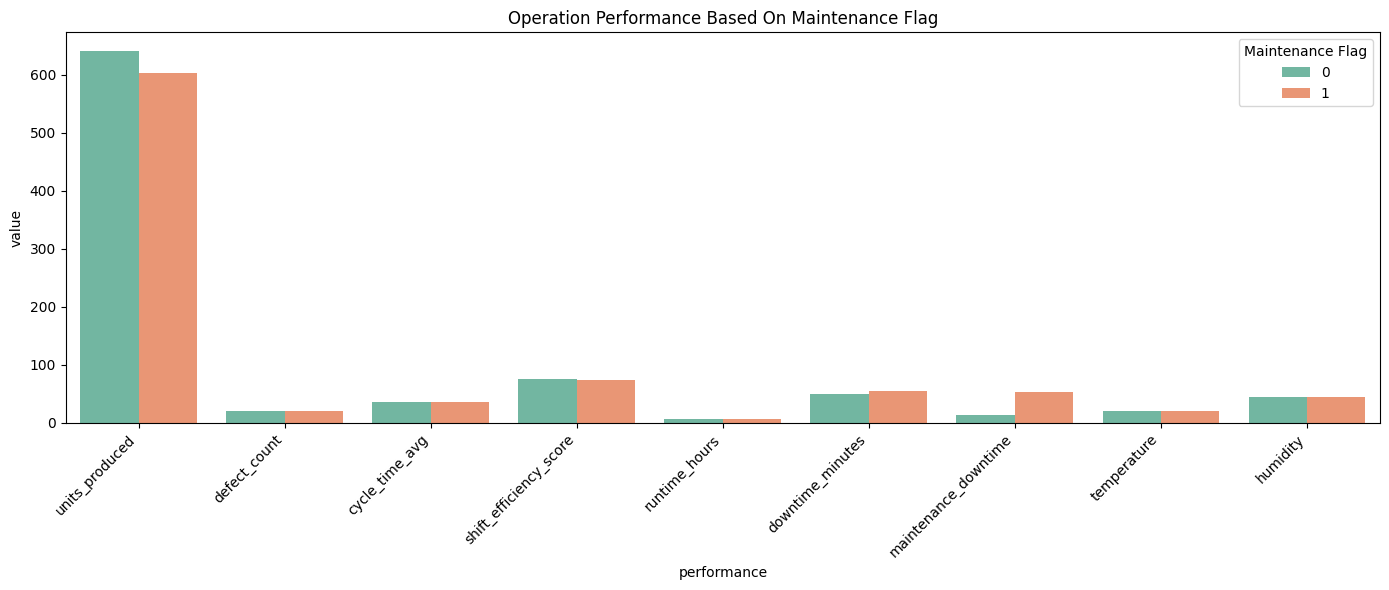

In [64]:
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars=['maintenance_flag'],
    var_name="performance",
    value_name='value'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=maintenance_plot_melt,
    x="performance",
    y="value",
    hue="maintenance_flag",
    palette="Set2"
)

plt.xticks(rotation=45, ha="right")
plt.title("Operation Performance Based On Maintenance Flag")
plt.legend(title="Maintenance Flag")
plt.tight_layout()
plt.show()

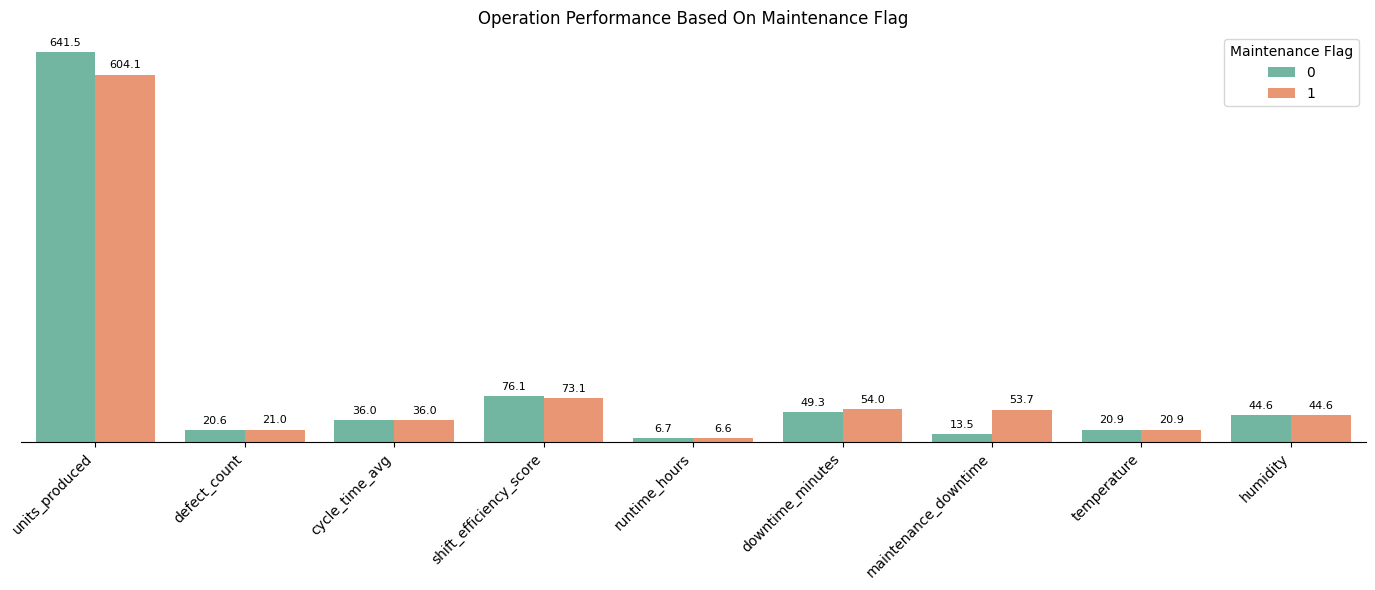

In [72]:
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars=['maintenance_flag'],
    var_name="performance",
    value_name='value'
)
plt.figure(figsize=(14, 6))
sns.barplot(
    data=maintenance_plot_melt,
    x="performance",
    y="value",
    hue="maintenance_flag",
    palette="Set2"
)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3, fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.title("Operation Performance Based On Maintenance Flag")
plt.ylabel("")
plt.xlabel("")
plt.legend(title="Maintenance Flag")
sns.despine(left=True)
plt.yticks([])
plt.tight_layout()
plt.show()